In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

In [8]:
test_dir = os.path.join("..", "data", "chest_xray", "test")
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Test data must only be rescaled, never augmented or shuffled
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 624 images belonging to 2 classes.


In [9]:
model_path = os.path.join("..", "models", "pneumonia_cnn_model.keras")

if os.path.exists(model_path):
    model = tf.keras.models.load_model(model_path)
    print("Model loaded successfully!")
else:
    print(f"Model file not found at {model_path}. Please check your path.")

Model loaded successfully!


In [10]:
# Evaluate loss and basic metrics
test_loss, test_acc, test_precision, test_recall = model.evaluate(test_generator)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Predict probabilities for the test set
Y_pred = model.predict(test_generator)
y_pred = np.where(Y_pred > 0.5, 1, 0)
y_true = test_generator.classes

# Print detailed Classification Report (Precision, Recall, F1-Score per class)
class_labels = list(test_generator.class_indices.keys())
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8317 - loss: 0.6358 - precision: 0.8013 - recall: 0.9718

Test Loss: 0.6358
Test Accuracy: 83.17%
Test Precision: 0.8013
Test Recall: 0.9718
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.93      0.60      0.73       234
   PNEUMONIA       0.80      0.97      0.88       390

    accuracy                           0.83       624
   macro avg       0.86      0.79      0.80       624
weighted avg       0.85      0.83      0.82       624



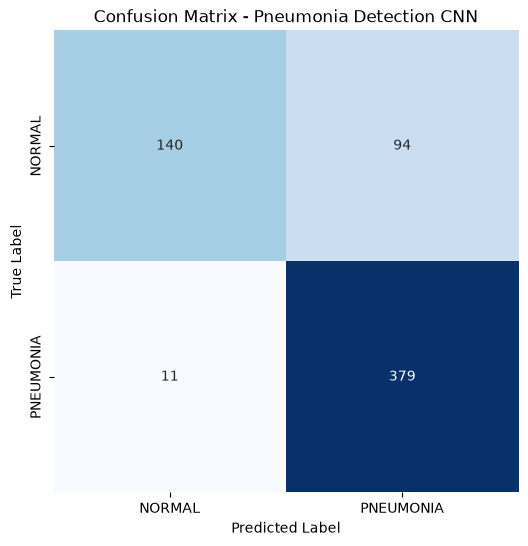

Confusion matrix saved to outputs/confusion_matrix.png


In [11]:
 # Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot using Seaborn
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Pneumonia Detection CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Save the plot into your outputs folder
os.makedirs("../outputs", exist_ok=True)
plt.savefig(os.path.join("../outputs", "confusion_matrix.png"))
plt.show()
print("Confusion matrix saved to outputs/confusion_matrix.png")